# Summary on using VAEs to compress stochastic logistic model

Author: Zhengqing Zhou
Updated: 2026/06/06

In this notebook, we recall the models trained on each dataset from a stochastic logistic model with different latent dimensions, and quantify the essential dimensionality for reconstructing n_target population dynamics

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import trange
from torch.nn import functional as F
from torch import nn

from sklearn.metrics import r2_score

from VAE_model import *

# Configure GPU if available
if torch.cuda.is_available():

    device = "cuda:0"
else:
    device = "cpu"

display(device)

'cuda:0'

## Visualize the target dynamics

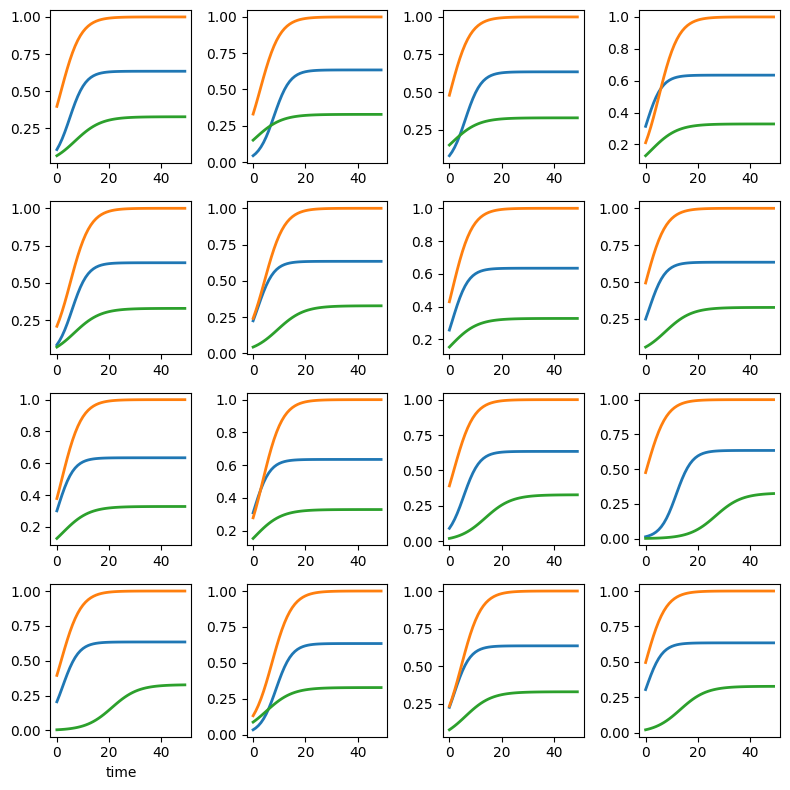

In [2]:
n_target = 3
model_index = 1
X_test = np.load(f"./saved_sims/I{model_index}/T{n_target}_test.npy")
fig,axes=plt.subplots(4,4,figsize=(8,8))
axes=axes.flat
for i,ax in enumerate(axes):
    y_target = X_test[i]
    for j in range(n_target):
        ax.plot(y_target[j,:],lw=2)
ax=axes[12]
ax.set_xlabel("time")
fig.tight_layout()
        

# Visualize the reconstruction of a given trained model

R2: 0.84, mse: 2.39e-03


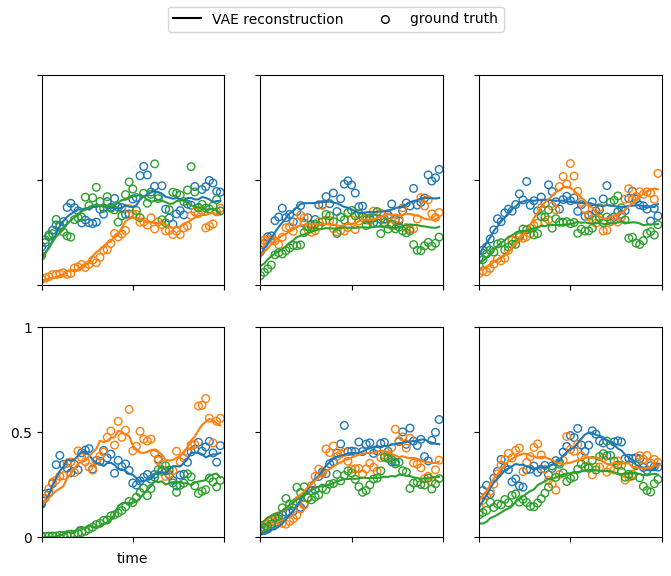

In [6]:
model_index=5
n_target=3
trial=1
x=np.arange(0,50,1)
n_embedding = 10

X_train, X_test = get_data(n_target, model_index)

batch=torch.Tensor(X_train).float()
n_show=6
tp_show=np.arange(0,50,5)
fig,axes=plt.subplots(2,3,figsize=(8,6))
axes=axes.flat

model = VAE(n_target,n_embedding)
model.to("cuda:0");
model.load_state_dict(
    torch.load(
        f"./vae_models/I{model_index}/slogistic_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
)
model.eval()

loss=0
with torch.no_grad():
    pred, code, mu, log_var = model(batch.to(device))
    pred=pred.cpu()
    loss=F.mse_loss(batch,pred).item()
r2 = r2_score(batch.flatten(),pred.flatten())
print(f"R2: {r2:.2f}, mse: {loss:.2e}")
np.random.seed(42)
idx_show = np.random.choice(np.arange(batch.shape[0]),n_show,replace=False)
for i,ii in enumerate(idx_show):
    ax=axes[i]
    data=batch[ii]
    rec=pred[ii]
    for k in range(n_target):
        l=ax.plot(x,rec[k,:],linewidth=1.5)
        ax.scatter(x,data[k,:],s=30,edgecolor=l[-1].get_color(),facecolor="None")
        ax.set_xlim([0,50])
        ax.set_xticks([0,25,50])
        ax.set_xticklabels([])
        ax.set_yticks([0,0.5,1])
        ax.set_yticklabels([])
    ax.set_ylim([0,1])
ax=axes[3]
ax.set_xticklabels([])
ax.set_xlabel("time")
ax.set_yticklabels([0,0.5,1])
ax.plot([],[],c="k",linewidth=1.5,label="VAE reconstruction")
ax.scatter([],[],s=30,edgecolor="k",facecolor="None",label="ground truth")
fig.legend(loc="upper center",ncol=2)

# Effective dimension of observable dynamics in stochastic logistic model

We define a function `get_error` which will return the MSE loss of the reconstruction of a `n_target` populations using an `n_embedding` dimensional VAE model. By iterating through all the parameters, we can then determine the essential dimensionality for the reconstruction of a given size target population dynamics.


In [3]:
def get_error(model,batch,):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_,mu,log_var = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch,reconstruction)
        r2 = r2_score(batch.flatten(), reconstruction.flatten())
        kld = (-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()))
    return mse,kld,r2

# logistic growth: autoregressive null model
model index = 1

In [5]:
model_index = 1
NT=np.arange(1,11,1)

N_EBD = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
for i,n_target in enumerate(NT):
    data_train = np.zeros((6,len(N_EBD)))
    data_train[0,:] = N_EBD
    data_test = np.zeros((6,len(N_EBD)))
    data_test[0,:] = N_EBD
    X_train, X_test = get_data(n_target, model_index)
    batch_train = torch.Tensor(X_train).float()
    batch_test = torch.Tensor(X_test).float()
    for trial in range(1,6,1):
        for j,n_embedding in enumerate(N_EBD):
            model = VAE(n_target,n_embedding)
            model.to("cuda:0");
            model.load_state_dict(
                torch.load(
                    f"./vae_models/I{model_index}/slogistic_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
            )
            mse_train,kld,r2_train=get_error(model,batch_train)
            data_train[trial,j]=(1-r2_train)*100
            mse_test,kld,r2_test=get_error(model,batch_test)
            data_test[trial,j]=(1-r2_test)*100
    save_dir = f"./saved_data/I{model_index}"
    os.makedirs(save_dir, exist_ok=True)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_train.txt", data_train)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt", data_test)
    print(f"model {model_index}; target {n_target} finished")

model 1; target 1 finished
model 1; target 2 finished
model 1; target 3 finished
model 1; target 4 finished
model 1; target 5 finished
model 1; target 6 finished
model 1; target 7 finished
model 1; target 8 finished
model 1; target 9 finished
model 1; target 10 finished


Text(0, 0.5, 'FUV%')

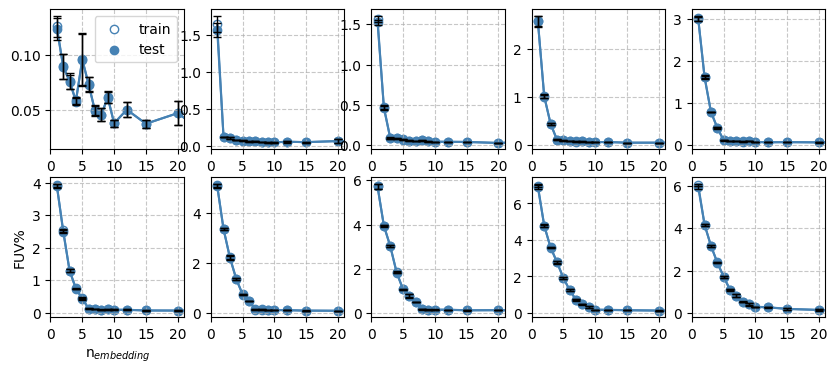

In [6]:
NT=np.arange(1,11,1)
n_trial = 5
model_index=1
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
for i,n_target in enumerate(NT):
    ax=axes[i]
    data_train = np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_train.txt")
    data_test=np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt")
    N_EBD = data_train[0,:]
    for j,data in enumerate([data_train,data_test]):
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        mfc = 'white' if j==0 else 'steelblue'
        ax.scatter(N_EBD,mean_FUV,facecolor=mfc,edgecolor='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        ax.plot(N_EBD,mean_FUV,c='steelblue')
    ax.set_xticks(np.arange(0,21,5))
    ax.set_xlim([0,21])
    ax.grid(True, linestyle='--', alpha=0.7)
ax=axes[0]
ax.scatter([],[],facecolor='white',edgecolor='steelblue',label='train')
ax.scatter([],[],facecolor='steelblue',edgecolor='steelblue',label='test')
ax.legend()
ax=axes[5]

ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")

Now fit the FUV-embedding relationship to an exponential threshold function

In [7]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

[2.26147022 2.57017827 0.0613395 ]
[3.78526755 1.35991208 0.03506598]
[5.33998123 0.94103274 0.04332464]
[6.25281562 0.7553647  0.06310927]
[7.89108334 0.59342307 0.06958378]
[8.65575124 0.52012988 0.10343931]
[10.27560024  0.42630051  0.11826048]
[11.5469883   0.38876977  0.12193128]
[11.69473481  0.33418058  0.16900445]


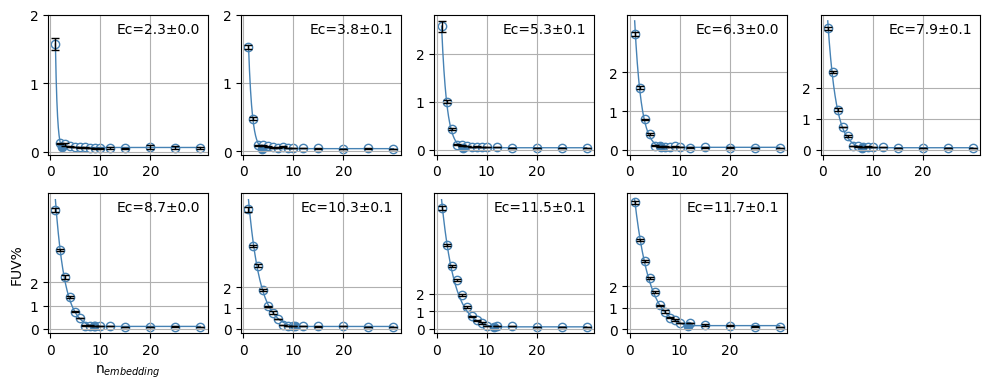

In [9]:
NT=np.arange(2,11,1)
n_trial = 5
model_index = 1
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    data=np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt")
    N_EBD=data[0,:]
    FUV = data[1:,:]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    
    popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, p0=(n_target, 1, 0.1))
    print(popt)
    Ec = popt[0]
    param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
    Ec_se = param_errors[0]
    Ec_data[1,i]=Ec
    Ec_data[2,i]=Ec_se
    y_Ec = y_exp(np.array([Ec]),*popt)
    ax.scatter(Ec,y_Ec,c='steelblue')
    xx=np.linspace(1,30,1000)
    yy=y_exp(xx,*popt)
    ax.plot(xx,yy,color="steelblue",linewidth=1)
    
    ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
    ax.set_xticks(np.arange(0,30,10))
    ax.set_yticks(np.arange(0,3,1))
    ax.grid(True)
axes[-1].set_visible(False)
fig.tight_layout()
np.savetxt(f"./saved_data/Ec_slogistic_model{model_index}.txt",Ec_data)

logistic model
Slope            : 1.287 ± 0.006 (SE)
Intercept        : -0.227 ± 0.028 (SE)
t-statistic      : 225.48  (dof = 7)
p-value (slope≠0): 8.88e-15
Weighted R²      : 0.994


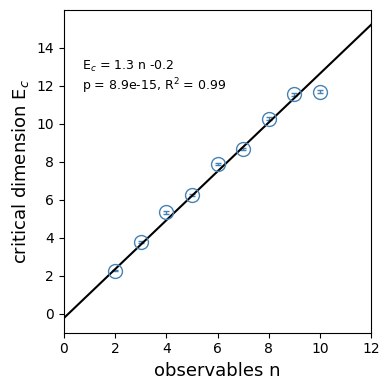

In [10]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b
model_index = 1
fig,ax = plt.subplots(1,1,figsize=(4,4))
data = np.loadtxt(f"./saved_data/Ec_slogistic_model{model_index}.txt")
# Extract x, y, and CI bounds
N_TG = data[0,:]
Ec = data[1,:]
Ec_se = data[2,:]
ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                elinewidth=1)

# Weighted fit using standard errors
popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
slope, intercept = popt
slope_se, intercept_se = np.sqrt(np.diag(pcov))

# residuals and total sums of squares
y_pred = linear_model(N_TG, slope, intercept)
SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)

R2 = 1 - SS_res / SS_tot

# Compute t-statistic and p-value
dof = len(N_TG) - 2
t_stat = slope / slope_se
p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

# Generate fit line and CI band
x_fit = np.linspace(0, 12, 100)
y_fit = linear_model(x_fit, slope, intercept)

ax.plot(x_fit,y_fit,c="k")
ax.set_xlim([0, 12])

# ----- formatted report ---------------------------------------------------
print(f"logistic model")
report = (
    f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
    f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
    f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
    f"p-value (slope≠0): {p_value:.3g}\n"
    f"Weighted R²      : {R2:.3f}"
)

print(report)

# Format regression equation
txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
ax.text(x=0.06, y=0.75, s=txt, transform=ax.transAxes, fontsize=9)
ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.tight_layout()

# stochastic logistic growth: increasing linear noise level
model index = 2 - 5

In [11]:
n_target = 3

N_EBD = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
for i,model_index in enumerate([2,3,4,5]):
    data_train = np.zeros((6,len(N_EBD)))
    data_train[0,:] = N_EBD
    data_test = np.zeros((6,len(N_EBD)))
    data_test[0,:] = N_EBD
    X_train, X_test = get_data(n_target, model_index)
    batch_train = torch.Tensor(X_train).float()
    batch_test = torch.Tensor(X_test).float()
    for trial in range(1,6,1):
        for j,n_embedding in enumerate(N_EBD):
            model = VAE(n_target,n_embedding)
            model.to("cuda:0");
            model.load_state_dict(
                torch.load(
                    f"./vae_models/I{model_index}/slogistic_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
            )
            mse_train,kld,r2_train=get_error(model,batch_train)
            data_train[trial,j]=(1-r2_train)*100
            mse_test,kld,r2_test=get_error(model,batch_test)
            data_test[trial,j]=(1-r2_test)*100
    save_dir = f"./saved_data/I{model_index}"
    os.makedirs(save_dir, exist_ok=True)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_train.txt", data_train)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt", data_test)
    print(f"model {model_index}; target {n_target} finished")

model 2; target 3 finished
model 3; target 3 finished
model 4; target 3 finished
model 5; target 3 finished


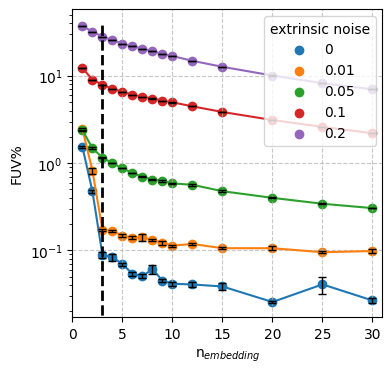

In [13]:
import matplotlib.pyplot as plt

colors = list(plt.cm.tab10.colors)
n_target = 3
n_trial = 5
fig,ax=plt.subplots(1,1,figsize=(4,4))
noise_level = {1:0, 2: 0.01, 3: 0.05, 4: 0.1, 5: 0.2}
for i,model_index in enumerate([1,2,3,4,5]):
    data=np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt")
    N_EBD = data[0,:]
    FUV = data[1:,:]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,color=colors[i],label=f"{noise_level[model_index]}")
    ax.plot(N_EBD,mean_FUV,c=colors[i])
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3)
ax.set_xticks(np.arange(0,31,5))
ax.set_xlim([0,31])

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(title='extrinsic noise')
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")
ax.plot([n_target,n_target],[-1,40],c='k',ls='--',linewidth=2)
#ax.set_ylim([-1,40])
ax.set_yscale("log")

# stochastic logistic growth: increasing sqrt noise level
model index = 6 - 9

In [14]:
n_target = 3

N_EBD = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
for i,model_index in enumerate([6,7,8,9]):
    data_train = np.zeros((6,len(N_EBD)))
    data_train[0,:] = N_EBD
    data_test = np.zeros((6,len(N_EBD)))
    data_test[0,:] = N_EBD
    X_train, X_test = get_data(n_target, model_index)
    batch_train = torch.Tensor(X_train).float()
    batch_test = torch.Tensor(X_test).float()
    for trial in range(1,6,1):
        for j,n_embedding in enumerate(N_EBD):
            model = VAE(n_target,n_embedding)
            model.to("cuda:0");
            model.load_state_dict(
                torch.load(
                    f"./vae_models/I{model_index}/slogistic_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
            )
            mse_train,kld,r2_train=get_error(model,batch_train)
            data_train[trial,j]=(1-r2_train)*100
            mse_test,kld,r2_test=get_error(model,batch_test)
            data_test[trial,j]=(1-r2_test)*100
    save_dir = f"./saved_data/I{model_index}"
    os.makedirs(save_dir, exist_ok=True)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_train.txt", data_train)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt", data_test)
    print(f"model {model_index}; target {n_target} finished")

model 6; target 3 finished
model 7; target 3 finished
model 8; target 3 finished
model 9; target 3 finished


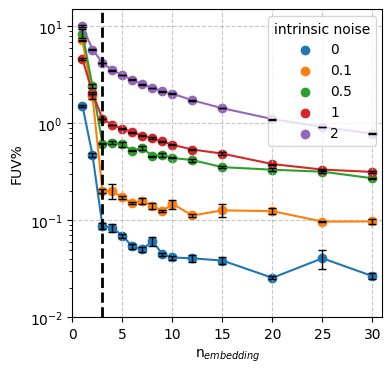

In [18]:
import matplotlib.pyplot as plt

colors = list(plt.cm.tab10.colors)
n_target = 3
n_trial = 5
fig,ax=plt.subplots(1,1,figsize=(4,4))
noise_level = {1: 0, 6: 0.1, 7: 0.5, 8: 1, 9: 2}
for i,model_index in enumerate([1,6,7,8,9]):
    #data_train = np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_train.txt")
    data=np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt")
    N_EBD = data[0,:]
    FUV = data[1:,:]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,color=colors[i],label=f"{noise_level[model_index]}")
    ax.plot(N_EBD,mean_FUV,c=colors[i])
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    
ax.set_xticks(np.arange(0,31,5))
ax.set_xlim([0,31])

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(title='intrinsic noise')
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")
ax.plot([n_target,n_target],[1e-2,15],c='k',ls='--',linewidth=2)
ax.set_ylim([1e-2,15])
ax.set_yscale("log")